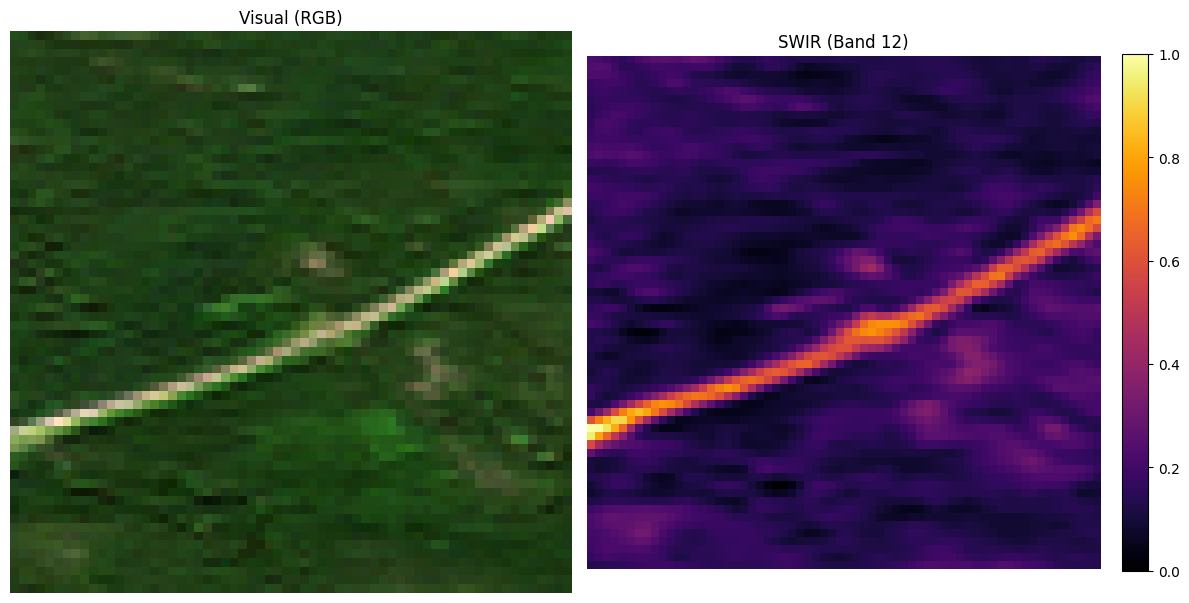

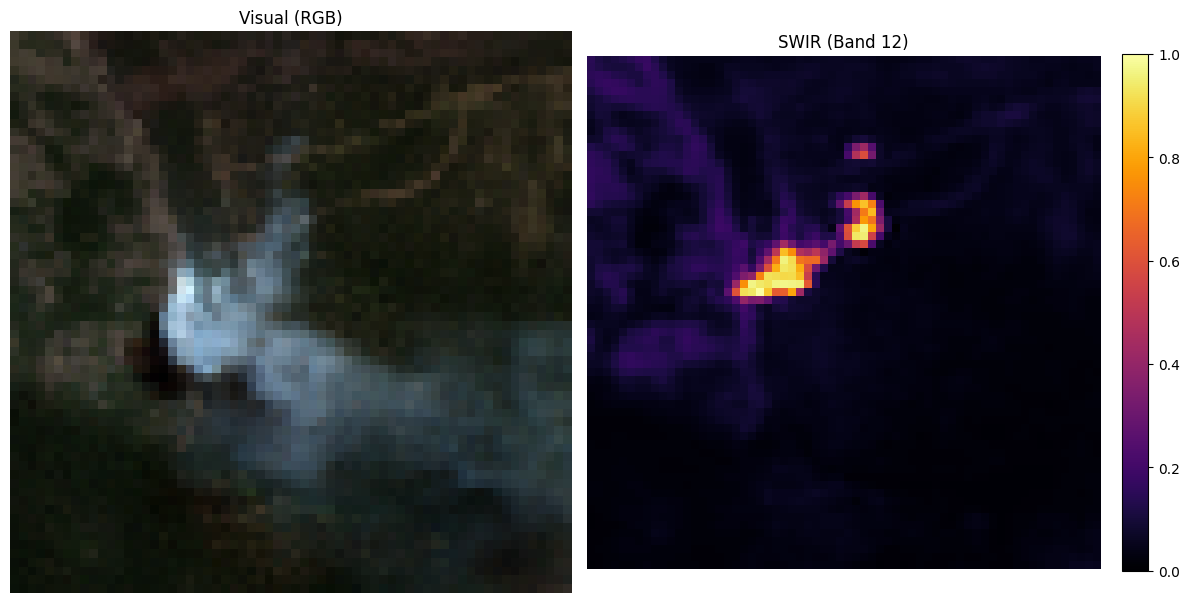

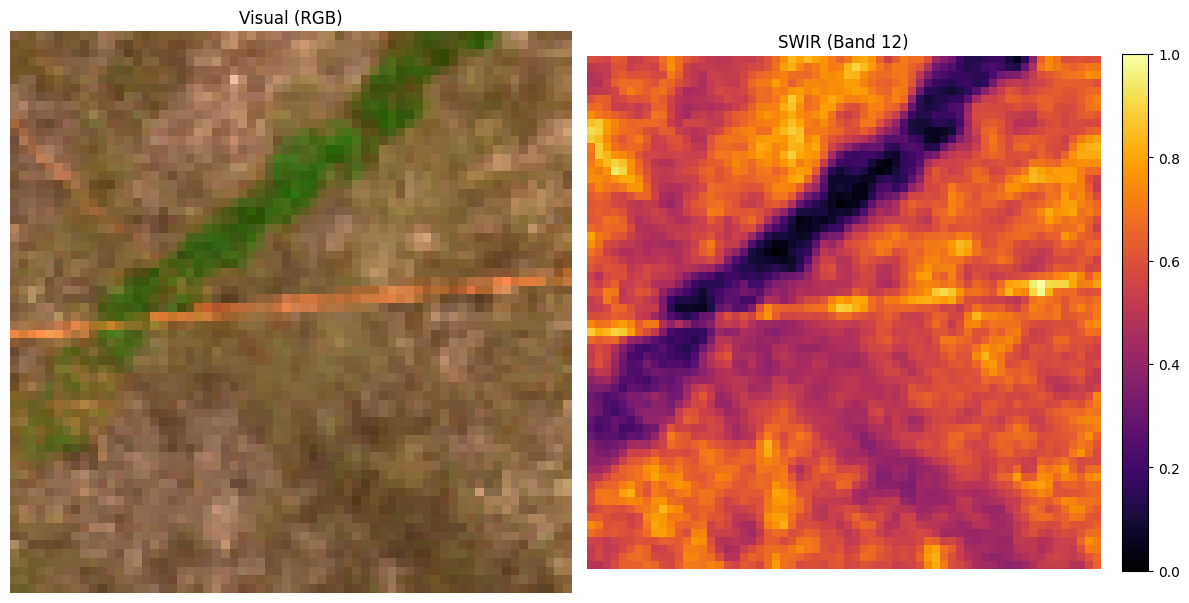

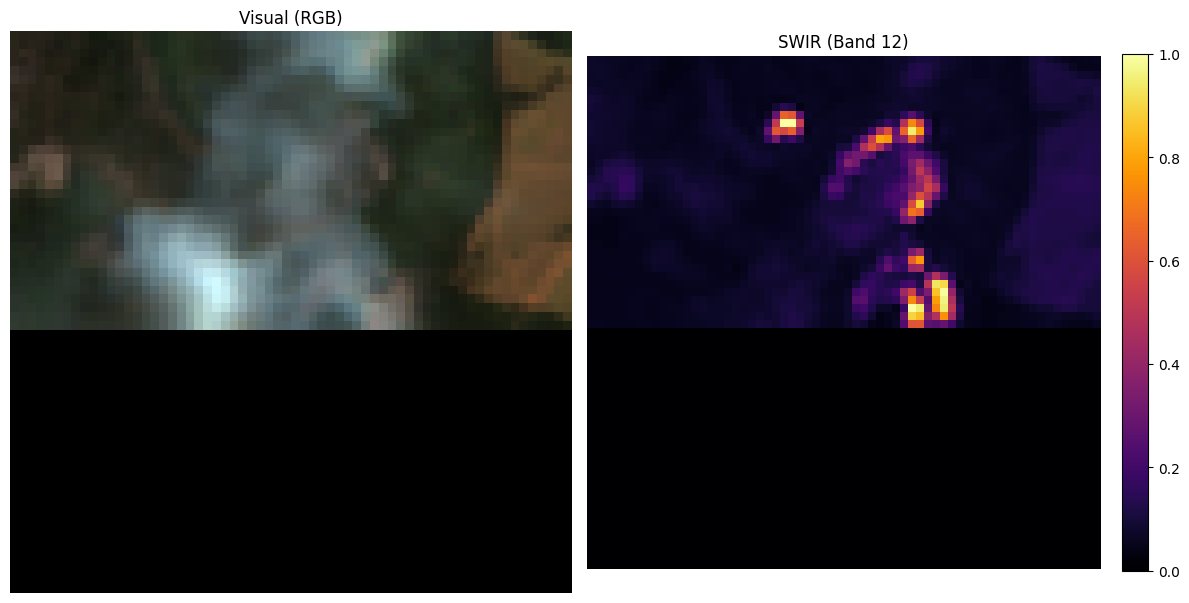

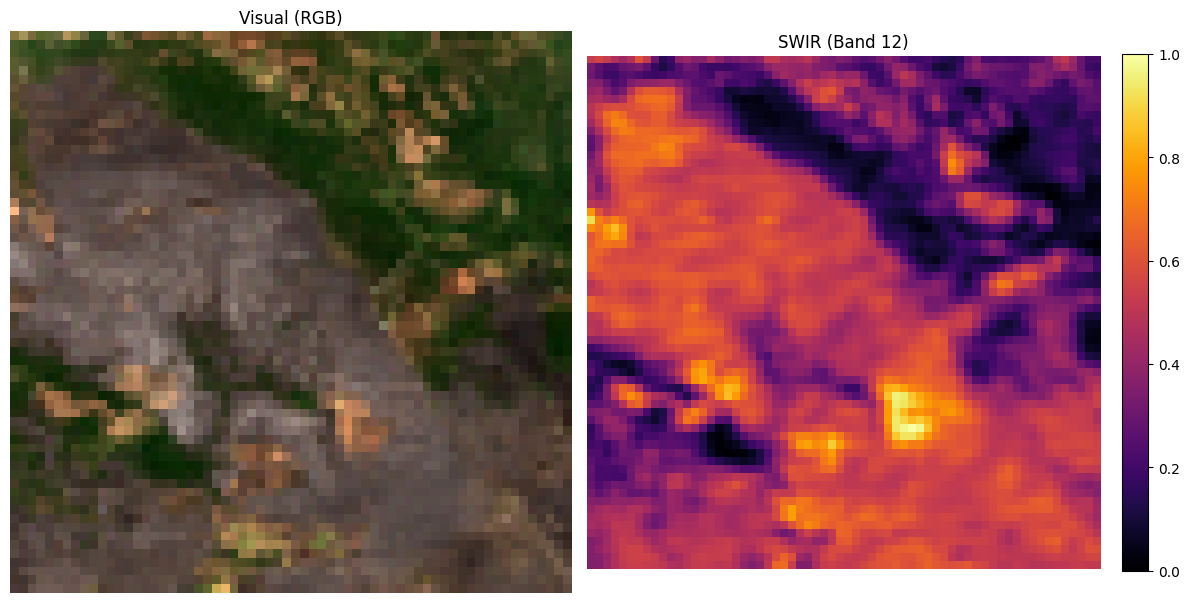

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_patch(file_path):
    # Load data
    data = np.load(file_path) # Expected shape (64, 64, 4) -> (Red, Green, Blue, SWIR)
    
    # Calculate global min/max for normalization (avoiding potential outliers slightly if needed, but simple min/max usually works for display)
    # The data is raw Sentinel-2 values (0-10000 approx)
    
    # Extract RGB bands (Indexes 0, 1, 2 = R, G, B)
    rgb = data[:, :, :3]
    
    # Normalize RGB for display (0-1 range). 
    # Using a clip at around 3000 (0.3 reflectance) often looks better for Sentinel-2 than pure min/max if there are bright clouds/fires.
    # But sticking to min/max per the user's previous style:
    rgb_norm = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    
    # Extract SWIR band (Index 3)
    swir = data[:, :, 3]
    
    # Create plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    # Display RGB
    ax[0].imshow(np.clip(rgb_norm, 0, 1))
    ax[0].set_title("Visual (RGB)")
    ax[0].axis('off')
    
    # Display SWIR (Thermal/Fire detection)
    # Normalize SWIR for better contrast in heatmap
    swir_norm = (swir - swir.min()) / (swir.max() - swir.min() + 1e-8)
    im = ax[1].imshow(swir_norm, cmap='inferno') # 'inferno' or 'hot' is good for fire
    ax[1].set_title("SWIR (Band 12)")
    ax[1].axis('off')
    
    plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Example
visualize_patch('./dataset/train/clean_russia_2208.npy')
visualize_patch('./dataset/test_fire/fire_australia_221520.npy')
visualize_patch('./dataset/test_fire/fire_brazil_403045.npy')
visualize_patch('./dataset/test_fire/fire_brazil_183838.npy')
visualize_patch('./dataset/test_fire/fire_morocco_87.npy')

